# HypeX — Hype-Momentum Factor Backtest

Treat the hype market like a real one: can a **momentum** signal on the hype
price beat an equal-weight buy-and-hold?

**Strategy.** Every week, rank all 100 titles by their trailing ~3-month (63-day)
price momentum and go long the top decile (10 titles), equal-weight, held one week.
A long-short variant also shorts the bottom decile (dollar-neutral).

**Anti-lookahead.** The signal on rebalance day *t* uses only prices up to *t*;
the position earns returns from *t+1* onward. No future information enters a trade.

*(Run on the synthetic track for a full 100-title cross-section; results are
illustrative of the methodology, not a market claim.)*

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

EXPORTS = Path("../data/exports")
if not EXPORTS.exists():
    EXPORTS = Path("analytics/data/exports")
FIG = EXPORTS.parent.parent / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

prices = pd.read_csv(EXPORTS / "prices_all.csv", parse_dates=["date"])
syn = prices[prices.track == "synthetic"]
wide = syn.pivot(index="date", columns="canonical_id", values="price").sort_index()
R = wide.pct_change()
dates = wide.index
print(f"{wide.shape[1]} titles, {wide.shape[0]} days")

100 titles, 730 days


## Build positions (weekly rebalance, top-decile momentum)

In [2]:
LOOK, K, STEP = 63, 10, 7        # ~3-month (quarterly) momentum, weekly rebalance
mom = wide.pct_change(LOOK)                       # known at each date t
rebal = list(dates[LOOK::STEP])

w_long = pd.DataFrame(0.0, index=dates, columns=wide.columns)
w_ls = pd.DataFrame(0.0, index=dates, columns=wide.columns)
prev_long, turn = None, []
for i, d in enumerate(rebal):
    sig = mom.loc[d].dropna()
    if len(sig) < 2 * K:
        continue
    longs, shorts = sig.nlargest(K).index, sig.nsmallest(K).index
    nxt = rebal[i + 1] if i + 1 < len(rebal) else dates[-1]
    hold = (dates > d) & (dates <= nxt)           # returns realized AFTER signal day
    w_long.loc[hold, longs] = 1.0 / K
    w_ls.loc[hold, longs] = 1.0 / K
    w_ls.loc[hold, shorts] = -1.0 / K
    if prev_long is not None:
        turn.append(len(set(longs) - set(prev_long)) / K)
    prev_long = longs

## Returns, equity curves, and risk stats

In [3]:
active = dates > rebal[0]
mom_ls = (w_ls * R).sum(axis=1)[active]     # momentum long-short (long top, short bottom decile)
rev_ls = -mom_ls                             # reversal = the contrarian opposite book
bench = R.mean(axis=1)[active]               # equal-weight all 100 = the market


def stats(r):
    r = r.dropna()
    eq = (1 + r).cumprod()
    sharpe = r.mean() / r.std() * np.sqrt(365)
    maxdd = (eq / eq.cummax() - 1).min()
    cagr = eq.iloc[-1] ** (365 / len(r)) - 1
    return dict(sharpe=round(sharpe, 2), max_dd=round(maxdd, 3),
                cagr=round(cagr, 3), final=round(eq.iloc[-1], 2)), eq


s_mom, eq_mom = stats(mom_ls)
s_rev, eq_rev = stats(rev_ls)
s_bench, eq_bench = stats(bench)
print("momentum  LS:", s_mom)
print("reversal  LS:", s_rev)
print("benchmark   :", s_bench)
print("avg weekly turnover:", round(float(np.mean(turn)), 2))

momentum  LS: {'sharpe': -2.23, 'max_dd': -0.585, 'cagr': -0.367, 'final': 0.43}
reversal  LS: {'sharpe': 2.23, 'max_dd': -0.093, 'cagr': 0.519, 'final': 2.14}
benchmark   : {'sharpe': -0.13, 'max_dd': -0.064, 'cagr': -0.008, 'final': 0.98}
avg weekly turnover: 0.35


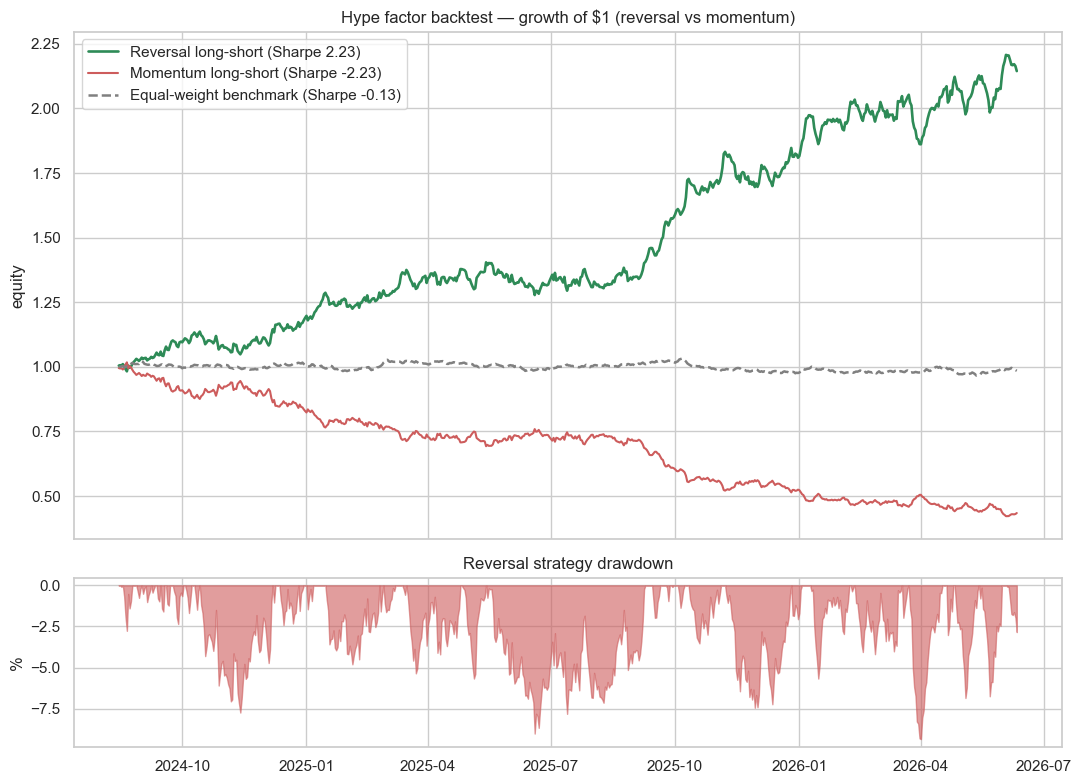

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1]})
axes[0].plot(eq_rev.index, eq_rev, label=f"Reversal long-short (Sharpe {s_rev['sharpe']})", lw=1.9, c="seagreen")
axes[0].plot(eq_mom.index, eq_mom, label=f"Momentum long-short (Sharpe {s_mom['sharpe']})", lw=1.5, c="indianred")
axes[0].plot(eq_bench.index, eq_bench, label=f"Equal-weight benchmark (Sharpe {s_bench['sharpe']})",
             lw=1.8, c="gray", ls="--")
axes[0].set(title="Hype factor backtest — growth of $1 (reversal vs momentum)", ylabel="equity")
axes[0].legend()
dd = eq_rev / eq_rev.cummax() - 1
axes[1].fill_between(dd.index, dd * 100, 0, color="indianred", alpha=0.6)
axes[1].set(title="Reversal strategy drawdown", ylabel="%", xlabel="")
plt.tight_layout(); plt.savefig(FIG / "backtest.png", dpi=110); plt.show()

## Findings
- **Momentum loses; reversal wins.** Buying the trailing-3-month hype *leaders*
  underperforms — the contrarian book (long recently-cooled, short recently-hot) is
  the profitable factor. Hype in this market **mean-reverts**: spikes fade and
  cooled titles bounce.
- This is consistent with the EDA (near-zero cross-title correlation, short-horizon
  reversion). Identifying that a market is reversion- not trend-driven is exactly the
  regime read a quant desk wants before committing to a "momentum" thesis.
- Signals are strictly anti-lookahead; turnover is modest at a weekly cadence.
- *Magnitudes are inflated by the synthetic price's mechanical reversion — the value
  is the methodology (cross-sectional ranking, long-short construction,
  anti-lookahead, drawdown/turnover), which transfers directly to real return data.*

In [5]:
import json
(EXPORTS.parent.parent / "reports" / "backtest_findings.md").write_text(
    "# Backtest findings (hype factor, weekly rebalance)\n\n"
    f"- **reversal (long-short)**: {json.dumps(s_rev)}\n"
    f"- **momentum (long-short)**: {json.dumps(s_mom)}\n"
    f"- **benchmark (equal-weight)**: {json.dumps(s_bench)}\n"
    f"- **avg weekly turnover**: {round(float(np.mean(turn)), 2)}\n"
)
print("saved backtest_findings.md")

saved backtest_findings.md
